In [17]:
import random
import time
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timedelta


In [18]:
import random
from datetime import datetime, timedelta

def generate_pengiriman(n):
    data = []
    base_time = datetime.now()

    for i in range(n):
        pengiriman = {
            "id_paket": f"PKT{i+1:04d}",
            "kurir": random.choice(["JNE", "J&T", "SiCepat", "AnterAja"]),
            "asal": random.choice(["Jakarta", "Bandung", "Surabaya"]),
            "tujuan": random.choice(["Purwokerto", "Yogyakarta", "Semarang"]),
            "waktu_pengiriman": base_time + timedelta(minutes=random.randint(0, 100000))
        }
        data.append(pengiriman)

    return data


In [19]:
import pandas as pd

data_pengiriman = generate_pengiriman(10)
df_pengiriman = pd.DataFrame(data_pengiriman)

df_pengiriman


,id_paket,kurir,asal,tujuan,waktu_pengiriman
0,PKT0001,AnterAja,Surabaya,Semarang,2026-01-14 01:09:35.435938
1,PKT0002,J&T,Bandung,Semarang,2025-12-24 07:15:35.435938
2,PKT0003,AnterAja,Bandung,Yogyakarta,2026-02-04 13:26:35.435938
3,PKT0004,SiCepat,Surabaya,Semarang,2026-01-22 01:20:35.435938
4,PKT0005,JNE,Surabaya,Purwokerto,2026-01-28 21:14:35.435938
5,PKT0006,J&T,Bandung,Semarang,2026-01-12 23:06:35.435938
6,PKT0007,AnterAja,Jakarta,Semarang,2026-02-02 22:17:35.435938
7,PKT0008,SiCepat,Surabaya,Semarang,2026-02-24 08:41:35.435938
8,PKT0009,SiCepat,Surabaya,Semarang,2025-12-20 04:34:35.435938
9,PKT0010,J&T,Surabaya,Purwokerto,2026-02-12 12:52:35.435938


In [20]:
def insertion_sort(data):
    arr = data.copy()
    for i in range(1, len(arr)):
        key = arr[i]
        j = i - 1
        while j >= 0 and arr[j]["waktu_pengiriman"] > key["waktu_pengiriman"]:
            arr[j + 1] = arr[j]
            j -= 1
        arr[j + 1] = key
    return arr

def merge_sort(data):
    if len(data) <= 1:
        return data

    mid = len(data) // 2
    left = merge_sort(data[:mid])
    right = merge_sort(data[mid:])
    return merge(left, right)

def merge(left, right):
    result = []
    i = j = 0

    while i < len(left) and j < len(right):
        if left[i]["waktu_pengiriman"] <= right[j]["waktu_pengiriman"]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1

    result.extend(left[i:])
    result.extend(right[j:])
    return result


In [21]:
sorted_iterative = insertion_sort(data_pengiriman)
sorted_recursive = merge_sort(data_pengiriman)

pd.DataFrame(sorted_iterative)


,id_paket,kurir,asal,tujuan,waktu_pengiriman
0,PKT0009,SiCepat,Surabaya,Semarang,2025-12-20 04:34:35.435938
1,PKT0002,J&T,Bandung,Semarang,2025-12-24 07:15:35.435938
2,PKT0006,J&T,Bandung,Semarang,2026-01-12 23:06:35.435938
3,PKT0001,AnterAja,Surabaya,Semarang,2026-01-14 01:09:35.435938
4,PKT0004,SiCepat,Surabaya,Semarang,2026-01-22 01:20:35.435938
5,PKT0005,JNE,Surabaya,Purwokerto,2026-01-28 21:14:35.435938
6,PKT0007,AnterAja,Jakarta,Semarang,2026-02-02 22:17:35.435938
7,PKT0003,AnterAja,Bandung,Yogyakarta,2026-02-04 13:26:35.435938
8,PKT0010,J&T,Surabaya,Purwokerto,2026-02-12 12:52:35.435938
9,PKT0008,SiCepat,Surabaya,Semarang,2026-02-24 08:41:35.435938


In [22]:
import time

input_sizes = [10, 50, 100, 500, 1000]
num_runs = 3

recursive_times = []
iterative_times = []

for n in input_sizes:
    rec_total = 0
    it_total = 0

    for _ in range(num_runs):
        data = generate_pengiriman(n)

        start = time.time()
        merge_sort(data)
        rec_total += time.time() - start

        start = time.time()
        insertion_sort(data)
        it_total += time.time() - start

    recursive_times.append(rec_total / num_runs)
    iterative_times.append(it_total / num_runs)


In [23]:
pd.options.display.float_format = '{:.6e}'.format

result_table = pd.DataFrame({
    "Jumlah Data Pengiriman": input_sizes,
    "Merge Sort (Rekursif)": recursive_times,
    "Insertion Sort (Iteratif)": iterative_times
})

result_table


,Jumlah Data Pengiriman,Merge Sort (Rekursif),Insertion Sort (Iteratif)
0,10,1.303355e-05,4.529953e-06
1,50,8.289019e-05,9.123484e-05
2,100,1.403491e-04,2.758503e-04
3,500,8.084774e-04,6.743431e-03
4,1000,1.690785e-03,2.727858e-02


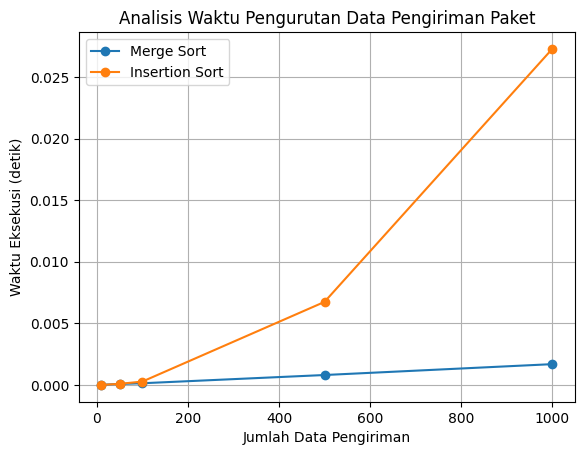

In [24]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(result_table["Jumlah Data Pengiriman"], result_table["Merge Sort (Rekursif)"], marker='o', label='Merge Sort')
plt.plot(result_table["Jumlah Data Pengiriman"], result_table["Insertion Sort (Iteratif)"], marker='o', label='Insertion Sort')

plt.xlabel("Jumlah Data Pengiriman")
plt.ylabel("Waktu Eksekusi (detik)")
plt.title("Analisis Waktu Pengurutan Data Pengiriman Paket")
plt.legend()
plt.grid(True)
plt.show()
